# Predictfy × Locaweb — Sprint 3 — Machine Learning

**Disciplina:** Machine Learning & Artificial Intelligence  
**Projeto e grupo:** Predictfy  
**Turma:** 2TSCPW · FIAP Challenge 2026

| Integrante | RM |
|---|---:|
| Elton Vinicios Almeida de Oliveira | 562187 |
| Emerson dos Santos Silva | 562033 |
| Kelvin Douglas Ribeiro Rabelo | 561538 |
| Pedro Henrique Simão Soares | 562283 |
| Vitor Lucas Mattos de Brito Mariano | 562116 |

## Objetivo

Investigar quais features temporais ajudam a prever o **volume diário de incidentes que entraram no KPI** e avaliar sua utilidade com um modelo simples e interpretável. Essa tarefa sustenta o planejamento de capacidade e as telas de Gestão e Monitoramento do Predictfy.

**Pergunta:** informações de calendário e somente volumes já encerrados até D−1 melhoram uma referência sazonal ingênua sem introduzir dados do futuro?

## 1. Protocolo e honestidade experimental

O XLSX oficial é reconstruído desde a origem. A unidade de análise é um dia civil e o alvo é a quantidade de incidentes abertos nesse dia com `Entrou para KPI? == "SIM"`.

- **2023–2024:** diagnóstico de cobertura, nunca treino principal, porque contém somente uma fração dos registros observados em 2025.
- **Treino:** 29/01/2025 a 30/06/2025, após formar os lags D−28.
- **Validação:** 01/07/2025 a 30/09/2025; confirma conjunto de features e regularização.
- **Backtest retrospectivo:** 01/10/2025 a 31/12/2025; usado uma única vez para diagnóstico final.
- Transformações são ajustadas somente no treino.
- Toda média móvel e todo lag usam `shift(1)`: o volume do próprio dia nunca entra como entrada.
- O segundo semestre de 2025 já foi estudado pelo projeto; por isso não é apresentado como teste prospectivo inédito.

In [1]:
import os
from pathlib import Path
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/predictfy-ml-mpl")
os.environ.setdefault("XDG_CACHE_HOME", "/private/tmp/predictfy-ml-cache")

import hashlib
import warnings

import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 80)
SEED = 42
np.random.seed(SEED)
print("Ambiente carregado | pandas", pd.__version__)

Ambiente carregado | pandas 3.0.5


In [2]:
candidates = []
if os.getenv("PREDICTFY_DATASET"):
    candidates.append(Path(os.environ["PREDICTFY_DATASET"]))
candidates.extend([
    Path("../../Challenge Locaweb - Sprint 1, 2, 3 e 4/lw-dataset/LW-DATASET.xlsx"),
    Path("../../locaweb/data/raw/LW-DATASET.xlsx"),
    Path("data/raw/LW-DATASET.xlsx"),
])
DATASET_PATH = next((p.resolve() for p in candidates if p.exists()), None)
if DATASET_PATH is None:
    raise FileNotFoundError(
        "LW-DATASET.xlsx não encontrado. Defina PREDICTFY_DATASET com o caminho do arquivo oficial."
    )

raw = pd.read_excel(DATASET_PATH)
required = {
    "Número", "Aberto", "Resolvido", "Encerrado", "Duração", "Prioridade",
    "Produto", "Categoria", "Subcategoria", "Status", "Entrou para KPI?", "KPI Violado?",
}
missing_columns = sorted(required - set(raw.columns))
if missing_columns:
    raise ValueError(f"Colunas obrigatórias ausentes: {missing_columns}")

dataset_sha256 = hashlib.sha256(DATASET_PATH.read_bytes()).hexdigest()
print("Arquivo:", DATASET_PATH.name)
print(f"Dimensão: {raw.shape[0]:,} linhas × {raw.shape[1]} colunas")
print("Período:", raw["Aberto"].min(), "a", raw["Aberto"].max())
print("SHA-256:", dataset_sha256)

Arquivo: LW-DATASET.xlsx
Dimensão: 122,543 linhas × 19 colunas
Período: 2023-01-02 20:19:58 a 2025-12-31 23:45:18
SHA-256: 87bab6e0625093ad4833a768d671fbac0405f08609103685fc6a0bccbee44959


## 2. Análise Exploratória de Dados (AED) — qualidade, nulos e dados inválidos

Primeiro auditamos o arquivo inteiro. Nulo não é automaticamente erro: em campos de classificação operacional, a ausência pode representar incidentes automáticos sem intervenção. A decisão de imputar depende do uso da coluna. O modelo diário usa somente a data de abertura, portanto não inventa categorias nem valores para os campos ausentes.

In [3]:
quality = pd.DataFrame({
    "tipo": raw.dtypes.astype(str),
    "nulos": raw.isna().sum(),
    "nulos_pct": (raw.isna().mean() * 100).round(2),
    "unicos": raw.nunique(dropna=True),
}).sort_values("nulos_pct", ascending=False)

exact_duplicates = int(raw.duplicated().sum())
duplicated_ids = int(raw["Número"].duplicated().sum())
opened_at = pd.to_datetime(raw["Aberto"], errors="coerce")
resolved_at = pd.to_datetime(raw["Resolvido"], errors="coerce")
closed_at = pd.to_datetime(raw["Encerrado"], errors="coerce")
invalid_open = int(opened_at.isna().sum())
invalid_duration = int((pd.to_numeric(raw["Duração"], errors="coerce") < 0).sum())
resolved_before_open = int(((resolved_at < opened_at) & resolved_at.notna()).sum())
closed_before_open = int(((closed_at < opened_at) & closed_at.notna()).sum())
invalid_kpi = sorted(set(raw["Entrou para KPI?"].dropna()) - {"SIM", "NAO"})
invalid_target = sorted(set(raw["KPI Violado?"].dropna()) - {"SIM", "NAO"})

display(quality)
display(pd.Series({
    "duplicatas_exatas": exact_duplicates,
    "ids_duplicados": duplicated_ids,
    "datas_abertura_invalidas": invalid_open,
    "duracoes_negativas": invalid_duration,
    "resolucoes_antes_abertura": resolved_before_open,
    "encerramentos_antes_abertura": closed_before_open,
    "rotulos_kpi_invalidos": invalid_kpi,
    "rotulos_target_invalidos": invalid_target,
}, name="auditoria"))

,tipo,nulos,nulos_pct,unicos
Incidente Pai,str,107416,87.66,3326
Solução,str,107243,87.51,2
KPI Violado?,str,96943,79.11,2
Resolvido,datetime64[us],82302,67.16,37446
Código de fechamento,str,81739,66.70,17
Produto,str,77935,63.60,51
Categoria,str,77721,63.42,141
Subcategoria,str,77720,63.42,447
Item de configuração,str,1780,1.45,9171
Entrou para KPI?,str,0,0.00,2


duplicatas_exatas                0
ids_duplicados                   0
datas_abertura_invalidas         0
duracoes_negativas               0
resolucoes_antes_abertura        0
encerramentos_antes_abertura     0
rotulos_kpi_invalidos           []
rotulos_target_invalidos        []
Name: auditoria, dtype: object

**Tratamento decidido**

- Aberturas inválidas seriam removidas, pois impedem a indexação temporal; datas de resolução/encerramento anteriores à abertura exigiriam correção na origem.
- Duplicatas exatas ou de `Número` seriam investigadas antes de qualquer remoção; o identificador é a chave de negócio.
- `Produto`, `Categoria` e `Subcategoria` não são imputados para o modelo de volume. Em um modelo categórico, a ausência seria preservada como `DESCONHECIDO`, pois pode ser informativa (MNAR).
- `Resolvido`, `Encerrado`, `Duração`, solução, código de fechamento e `KPI Violado?` são posteriores à abertura e ficam proibidos no modelo.

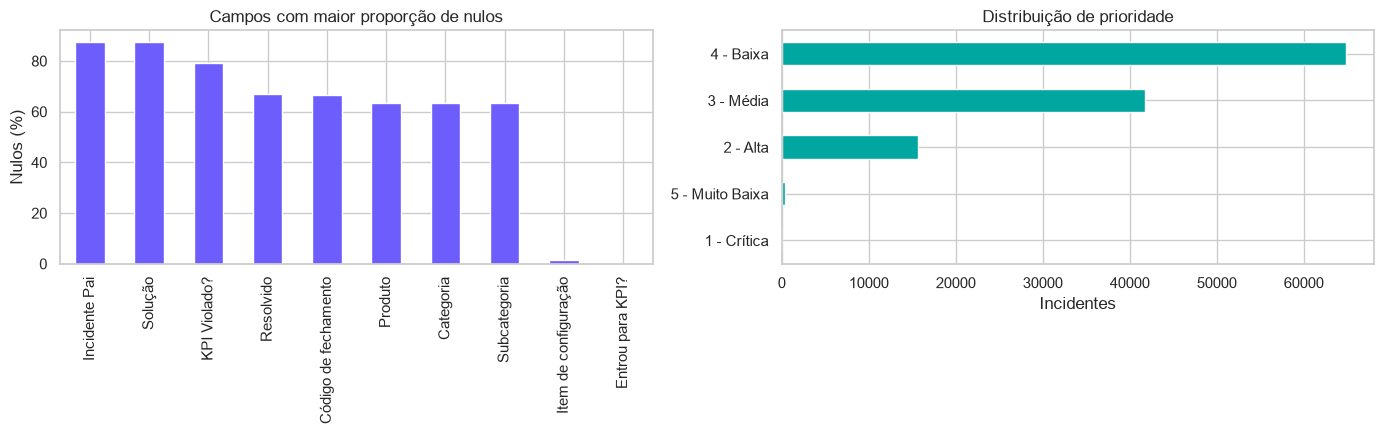

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
(raw.isna().mean().sort_values(ascending=False).head(10) * 100).plot.bar(ax=axes[0], color="#6d5dfc")
axes[0].set(title="Campos com maior proporção de nulos", ylabel="Nulos (%)", xlabel="")
raw["Prioridade"].value_counts().sort_values().plot.barh(ax=axes[1], color="#00a7a0")
axes[1].set(title="Distribuição de prioridade", xlabel="Incidentes", ylabel="")
plt.tight_layout()
plt.show()

In [5]:
eda_kpi_2025 = raw.loc[
    raw["Entrou para KPI?"].eq("SIM") & raw["Aberto"].dt.year.eq(2025)
].copy()
categorical_profile = []
for column in ("Produto", "Categoria", "Subcategoria"):
    profiled = eda_kpi_2025[column].fillna("DESCONHECIDO").value_counts(dropna=False).head(8)
    for value, count in profiled.items():
        categorical_profile.append({"campo": column, "valor": value, "incidentes": count})
display(pd.DataFrame(categorical_profile))
print(
    "Imputação apenas descritiva: DESCONHECIDO preserva a ausência como categoria; "
    "essas colunas não entram no modelo diário e, portanto, não recebem moda, média ou KNN."
)

,campo,valor,incidentes
0,Produto,lhco,8131
1,Produto,lcem,3496
2,Produto,lsin,3190
3,Produto,lhvp,1888
4,Produto,lrev,1821
5,Produto,lcsi,1058
6,Produto,lsaa,554
7,Produto,lcho,511
8,Categoria,cat71,3562
9,Categoria,cat85,3438


Imputação apenas descritiva: DESCONHECIDO preserva a ausência como categoria; essas colunas não entram no modelo diário e, portanto, não recebem moda, média ou KNN.


In [6]:
coverage = pd.crosstab(raw["Aberto"].dt.year, raw["Entrou para KPI?"], margins=True)
kpi_by_year_priority = pd.crosstab(
    raw.loc[raw["Entrou para KPI?"].eq("SIM"), "Aberto"].dt.year,
    raw.loc[raw["Entrou para KPI?"].eq("SIM"), "Prioridade"],
    margins=True,
)
display(coverage)
display(kpi_by_year_priority)

yearly = raw.assign(ano=raw["Aberto"].dt.year).groupby("ano").agg(
    incidentes=("Número", "size"),
    dias_observados=("Aberto", lambda s: s.dt.normalize().nunique()),
)
yearly["incidentes_por_dia_observado"] = yearly["incidentes"] / yearly["dias_observados"]
display(yearly.round(2))
print("Decisão: 2023–2024 ficam fora do treino principal por quebra de cobertura; a modelagem usa 2025 real.")

Entrou para KPI?,NAO,SIM,All
Aberto,,,
2023,23,87,110
2024,265,357,622
2025,96655,25156,121811
All,96943,25600,122543


Prioridade,2 - Alta,3 - Média,All
Aberto,,,
2023,0,87,87
2024,0,357,357
2025,5159,19997,25156
All,5159,20441,25600


,incidentes,dias_observados,incidentes_por_dia_observado
ano,,,
2023,110,83,1.33
2024,622,196,3.17
2025,121811,365,333.73


Decisão: 2023–2024 ficam fora do treino principal por quebra de cobertura; a modelagem usa 2025 real.


## 3. Distribuições e outliers

A duração é examinada apenas para descrever a qualidade e a operação. Ela só existe depois da resolução/encerramento, então não pode explicar uma previsão feita na abertura. Valores extremos de duração são ocorrências de negócio potencialmente legítimas; removê-los automaticamente esconderia os incidentes mais críticos.

,duracao_segundos
count,1.225430e+05
mean,2.485470e+05
std,2.480123e+06
min,1.000000e+00
50%,9.780000e+02
90%,1.843480e+04
95%,1.010522e+05
99%,6.157757e+06
max,8.828048e+07
limite_IQR,1.020675e+04


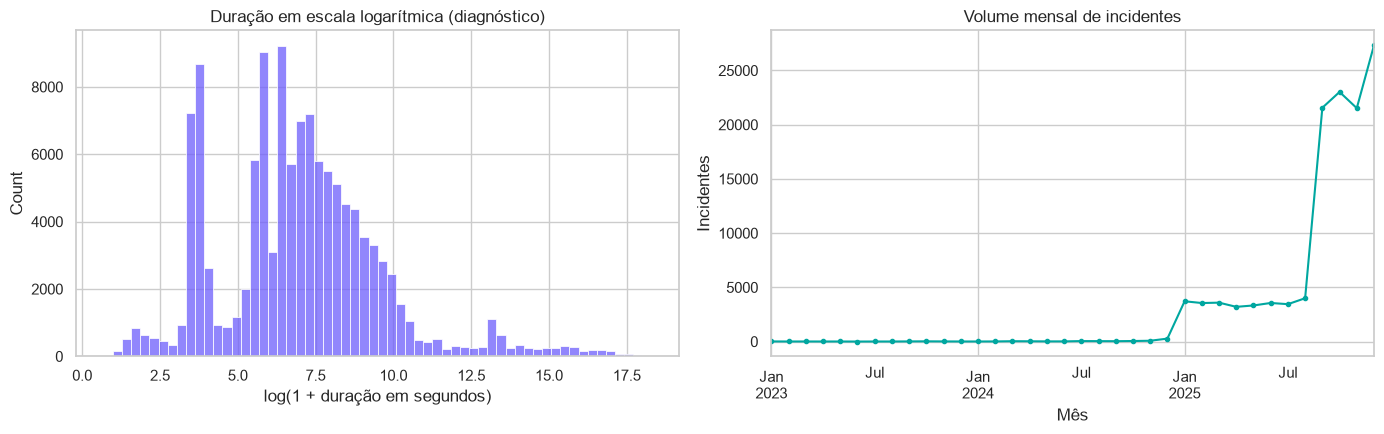

In [7]:
duration = pd.to_numeric(raw["Duração"], errors="coerce")
q1, q3 = duration.quantile([0.25, 0.75])
iqr = q3 - q1
upper_iqr = q3 + 1.5 * iqr
duration_summary = duration.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame("duracao_segundos")
duration_summary.loc["limite_IQR"] = upper_iqr
duration_summary.loc["acima_limite_IQR"] = int((duration > upper_iqr).sum())
display(duration_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(np.log1p(duration), bins=60, ax=axes[0], color="#6d5dfc")
axes[0].set(title="Duração em escala logarítmica (diagnóstico)", xlabel="log(1 + duração em segundos)")
monthly_raw = raw.assign(mes_abertura=pd.to_datetime(raw["Aberto"]).dt.to_period("M")).groupby("mes_abertura").size()
monthly_raw.index = monthly_raw.index.to_timestamp()
monthly_raw.plot(ax=axes[1], color="#00a7a0", marker="o", ms=3)
axes[1].set(title="Volume mensal de incidentes", xlabel="Mês", ylabel="Incidentes")
plt.tight_layout()
plt.show()

## 4. Série diária e Engenharia de Features

O calendário é reindexado explicitamente: um dia sem registro passa a ter volume zero, em vez de desaparecer da série. Todas as estatísticas móveis recebem `shift(1)` antes da janela.

| Família | Features | Vantagem | Limitação |
|---|---|---|---|
| Calendário | dia da semana, mês, fim de semana, feriado | Conhecidas antecipadamente e explicáveis | Não se adaptam sozinhas a mudança de regime |
| Cíclicas | seno/cosseno semanal e anual | Respeitam a proximidade entre fim e início do ciclo | Pressupõem ciclo suave |
| Lags | total D−1/D−7/D−14/D−21/D−28 | Capturam persistência e sazonalidade real | Indisponíveis no início e propagam choques passados |
| Composição | participação de P2 em D−1 e D−7 | Resume a mistura P2/P3 sem duplicar `total = P2 + P3` | Pode ser instável em dias de baixo volume |
| Janelas | média D−7/D−14/D−28 e desvio D−7/D−28 | Resumem nível e volatilidade recentes | Reagem com atraso a mudanças abruptas |
| Mudança de regime | diferença D−1 versus D−8 e média D−7 versus D−28 | Resume aceleração/desaceleração com dados encerrados | Pode reagir a ruído de curto prazo |
| Tendência anual | seno/cosseno anual e dias desde o início | Útil para diagnóstico visual | Não entra na seleção: há apenas um ciclo anual completo e a extrapolação seria frágil |

In [8]:
kpi = raw.loc[raw["Entrou para KPI?"].eq("SIM")].copy()
kpi["data"] = pd.to_datetime(kpi["Aberto"], errors="coerce").dt.normalize()
kpi_2025 = kpi.loc[kpi["data"].dt.year.eq(2025)].copy()
calendar = pd.date_range("2025-01-01", "2025-12-31", freq="D")
daily = kpi_2025.groupby("data").size().rename("volume_dia").reindex(calendar, fill_value=0).to_frame()
for label, suffix in (("2 - Alta", "p2"), ("3 - Média", "p3")):
    daily[f"volume_{suffix}"] = (
        kpi_2025.loc[kpi_2025["Prioridade"].eq(label)]
        .groupby("data").size().reindex(calendar, fill_value=0)
    )
daily.index.name = "data"
assert (daily["volume_p2"] + daily["volume_p3"] == daily["volume_dia"]).all()

idx = daily.index
daily["dia_semana"] = idx.dayofweek
daily["mes"] = idx.month
daily["dia_mes"] = idx.day
daily["is_fim_semana"] = (idx.dayofweek >= 5).astype(int)
br_sp_holidays = holidays.country_holidays("BR", subdiv="SP", years=range(idx.min().year, idx.max().year + 1))
daily["is_feriado"] = [int(d.date() in br_sp_holidays) for d in idx]
daily["semana_sin"] = np.sin(2 * np.pi * idx.dayofweek / 7)
daily["semana_cos"] = np.cos(2 * np.pi * idx.dayofweek / 7)
daily["ano_sin"] = np.sin(2 * np.pi * idx.dayofyear / 365.25)
daily["ano_cos"] = np.cos(2 * np.pi * idx.dayofyear / 365.25)
daily["tendencia_dias"] = np.arange(len(daily))

past = daily["volume_dia"].shift(1)
for lag in (1, 7, 8, 14, 21, 28):
    daily[f"lag_{lag}d"] = daily["volume_dia"].shift(lag)
for suffix in ("p2", "p3"):
    daily[f"lag_1d_{suffix}"] = daily[f"volume_{suffix}"].shift(1)
    daily[f"lag_7d_{suffix}"] = daily[f"volume_{suffix}"].shift(7)
daily["share_p2_1d"] = daily["lag_1d_p2"] / daily["lag_1d"].replace(0, np.nan)
daily["share_p2_7d"] = daily["lag_7d_p2"] / daily["lag_7d"].replace(0, np.nan)
daily["media_7d"] = past.rolling(7).mean()
daily["media_14d"] = past.rolling(14).mean()
daily["desvio_7d"] = past.rolling(7).std()
daily["media_28d"] = past.rolling(28).mean()
daily["desvio_28d"] = past.rolling(28).std()
daily["delta_semanal_d1"] = daily["lag_1d"] - daily["lag_8d"]
daily["delta_nivel_7_28"] = daily["media_7d"] - daily["media_28d"]
model_df = daily.drop(columns=[
    "volume_p2", "volume_p3", "lag_1d_p2", "lag_7d_p2", "lag_1d_p3", "lag_7d_p3",
]).dropna().copy()

print(f"Calendário KPI 2025: {len(daily):,} dias | incidentes: {int(daily.volume_dia.sum()):,}")
print(f"P2: {int(daily.volume_p2.sum()):,} | P3: {int(daily.volume_p3.sum()):,} | dias sem KPI: {(daily.volume_dia == 0).sum()}")
print(f"Base modelável após lags: {len(model_df):,} dias × {model_df.shape[1]} colunas")
display(model_df.head(3))
model_missing = model_df.isna().sum().to_frame("nulos_pos_feature_engineering")
display(model_missing)
assert model_missing["nulos_pos_feature_engineering"].sum() == 0
print("Imputação no dataset modelável: nenhuma; os 28 dias iniciais incompletos foram excluídos.")

Calendário KPI 2025: 365 dias | incidentes: 25,156
P2: 5,159 | P3: 19,997 | dias sem KPI: 0
Base modelável após lags: 337 dias × 26 colunas


,volume_dia,dia_semana,mes,dia_mes,is_fim_semana,is_feriado,semana_sin,semana_cos,ano_sin,ano_cos,tendencia_dias,lag_1d,lag_7d,lag_8d,lag_14d,lag_21d,lag_28d,share_p2_1d,share_p2_7d,media_7d,media_14d,desvio_7d,media_28d,desvio_28d,delta_semanal_d1,delta_nivel_7_28
data,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-01-29,113,2,1,29,0,0,0.974928,-0.222521,0.478434,0.878124,28,98.0,100.0,90.0,90.0,88.0,10.0,0.204082,0.250000,84.857143,81.928571,22.214324,70.357143,31.745766,8.0,14.500000
2025-01-30,186,3,1,30,0,0,0.433884,-0.900969,0.493468,0.869764,29,113.0,96.0,100.0,107.0,133.0,42.0,0.194690,0.312500,86.714286,83.571429,24.150323,74.035714,30.433269,13.0,12.678571
2025-01-31,88,4,1,31,0,0,-0.433884,-0.900969,0.508356,0.861147,30,186.0,69.0,96.0,104.0,66.0,50.0,0.096774,0.202899,99.571429,89.214286,44.932754,79.178571,36.401113,90.0,20.392857


,nulos_pos_feature_engineering
volume_dia,0
dia_semana,0
mes,0
dia_mes,0
is_fim_semana,0
is_feriado,0
semana_sin,0
semana_cos,0
ano_sin,0
ano_cos,0


Imputação no dataset modelável: nenhuma; os 28 dias iniciais incompletos foram excluídos.


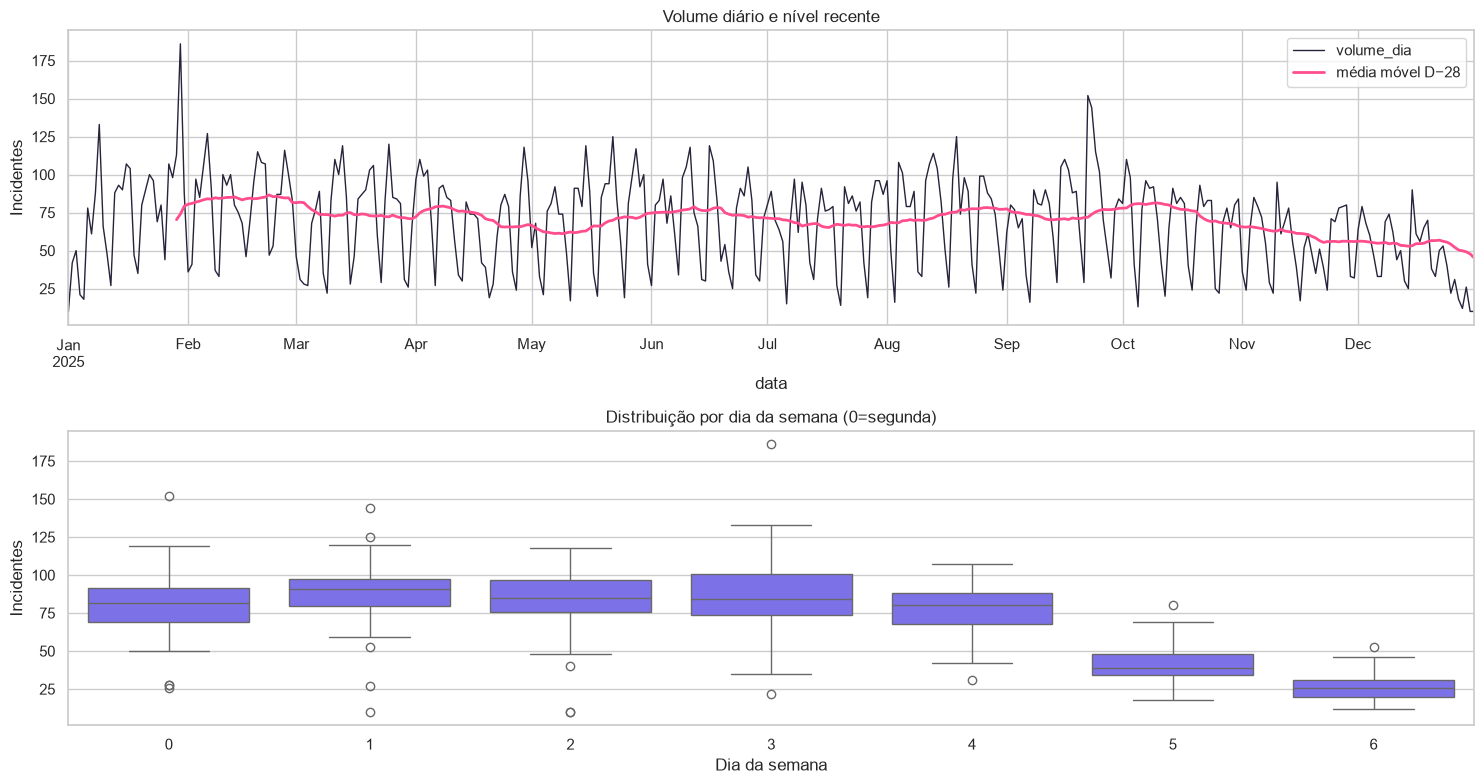

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))
daily["volume_dia"].plot(ax=axes[0], color="#27233a", lw=1)
daily["media_28d"].plot(ax=axes[0], color="#ff4d8d", lw=2, label="média móvel D−28")
axes[0].set(title="Volume diário e nível recente", ylabel="Incidentes")
axes[0].legend()
sns.boxplot(data=daily.reset_index(), x="dia_semana", y="volume_dia", ax=axes[1], color="#6d5dfc")
axes[1].set(title="Distribuição por dia da semana (0=segunda)", xlabel="Dia da semana", ylabel="Incidentes")
plt.tight_layout()
plt.show()

## 5. Tendência, sazonalidade e estacionariedade

A aula de forecast recomenda decompor a série e investigar autocorrelação antes da modelagem. Usamos decomposição **aditiva** com período 7, coerente com a sazonalidade semanal. O teste ADF e a ACF são diagnósticos calculados somente no treino; o enunciado descarta ARIMA/SARIMA como abordagem principal para este caso multidimensional.

Se a série em nível não rejeitar raiz unitária, o tratamento adotado será: ordem cronológica, lags, regularização e a diferença semanal `D−1 − D−8`, calculada somente com informação encerrada. A diferença é avaliada como feature de mudança de regime (`delta_semanal_d1`) e sua estacionariedade é verificada no treino. Tendência linear e ciclo anual permanecem na EDA, mas ficam fora da seleção principal porque existe apenas um ciclo anual com cobertura suficiente.

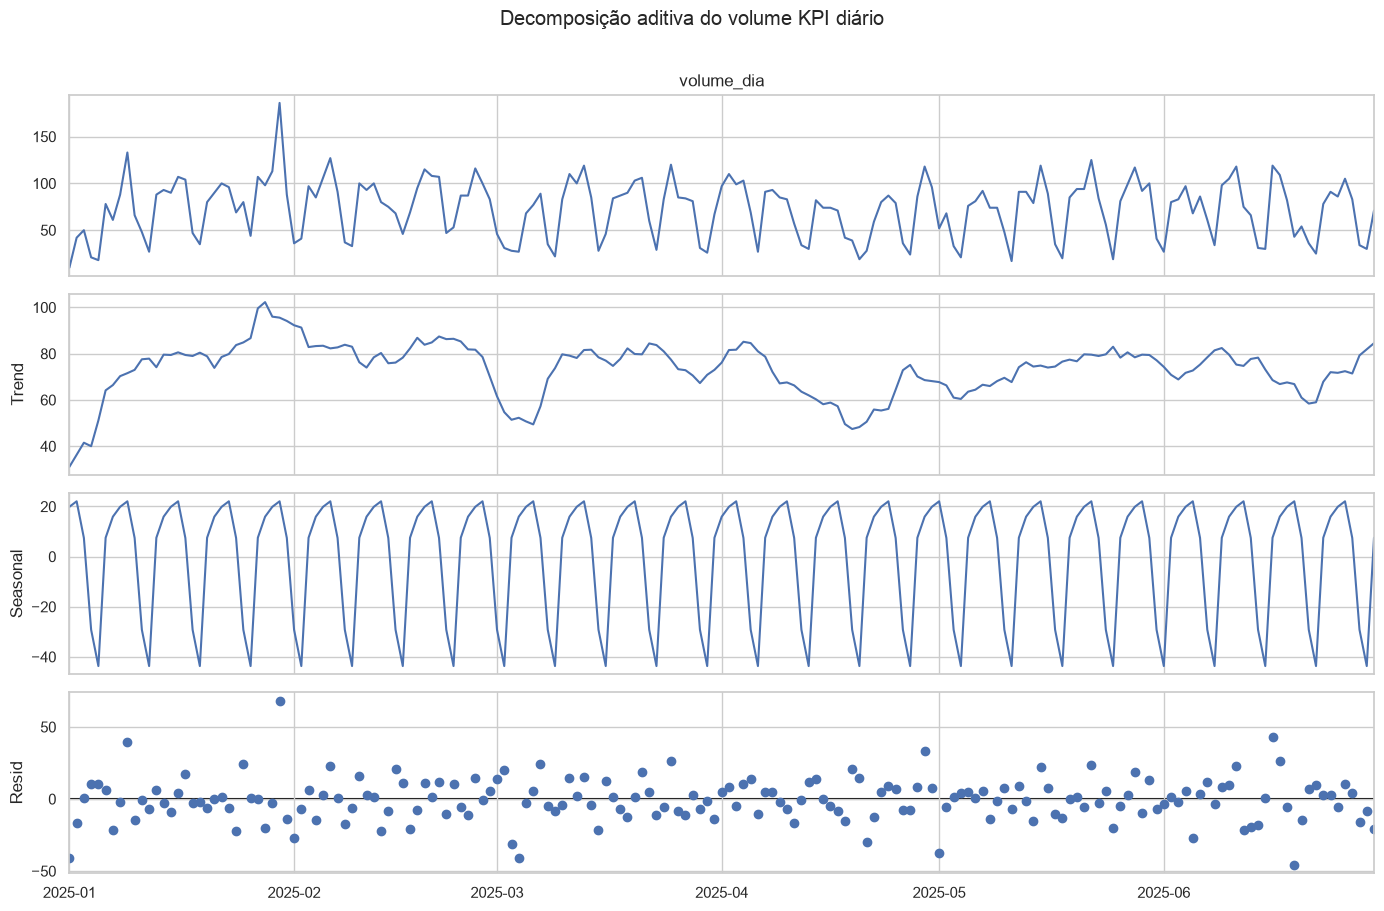

estatística_ADF                       -2.528028
p_valor                                0.108803
lags_usados                                  13
observações                                 167
interpretação_5pct    não rejeita raiz unitária
Name: ADF, dtype: object

estatística_ADF_diferenca_semanal                -5.330135
p_valor_diferenca_semanal                         0.000005
lags_usados                                             13
observações                                            160
interpretação_5pct                   rejeita raiz unitária
Name: ADF da diferença semanal, dtype: object

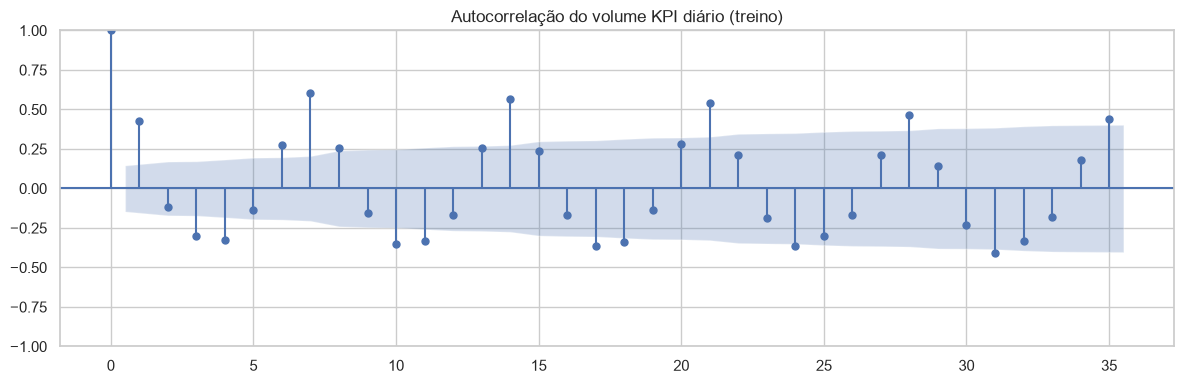

In [10]:
diagnostic_series = daily.loc[:"2025-06-30", "volume_dia"]
decomposition = seasonal_decompose(diagnostic_series, model="additive", period=7, extrapolate_trend="freq")
fig = decomposition.plot()
fig.set_size_inches(14, 9)
fig.suptitle("Decomposição aditiva do volume KPI diário", y=1.01)
plt.tight_layout()
plt.show()

adf_stat, adf_pvalue, adf_lags, adf_nobs, *_ = adfuller(diagnostic_series, autolag="AIC")
weekly_difference = diagnostic_series.diff(7).dropna()
adf_diff_stat, adf_diff_pvalue, adf_diff_lags, adf_diff_nobs, *_ = adfuller(weekly_difference, autolag="AIC")
display(pd.Series({
    "estatística_ADF": adf_stat,
    "p_valor": adf_pvalue,
    "lags_usados": adf_lags,
    "observações": adf_nobs,
    "interpretação_5pct": "rejeita raiz unitária" if adf_pvalue < 0.05 else "não rejeita raiz unitária",
}, name="ADF"))
display(pd.Series({
    "estatística_ADF_diferenca_semanal": adf_diff_stat,
    "p_valor_diferenca_semanal": adf_diff_pvalue,
    "lags_usados": adf_diff_lags,
    "observações": adf_diff_nobs,
    "interpretação_5pct": "rejeita raiz unitária" if adf_diff_pvalue < 0.05 else "não rejeita raiz unitária",
}, name="ADF da diferença semanal"))
assert adf_diff_pvalue < 0.05, "A diferença semanal deveria ser estacionária no treino"
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(diagnostic_series, lags=35, ax=ax, alpha=0.05)
ax.set_title("Autocorrelação do volume KPI diário (treino)")
plt.tight_layout()
plt.show()

## 6. Correlações e auditoria de data leakage

Correlação é descritiva, não causal. Para reduzir redundância, inspecionamos apenas variáveis numéricas. Correlações altas entre lags e médias móveis são esperadas e justificam testar Ridge, cuja regularização estabiliza coeficientes correlacionados.

,pearson,spearman
is_fim_semana,-0.770626,-0.735410
semana_sin,0.690930,0.679373
lag_7d,0.660334,0.606447
lag_21d,0.659127,0.591173
lag_14d,0.649508,0.595061
dia_semana,-0.609140,-0.592294
lag_28d,0.542163,0.509712
lag_1d,0.436393,0.473298
share_p2_7d,-0.363229,-0.283900
lag_8d,0.290886,0.295251


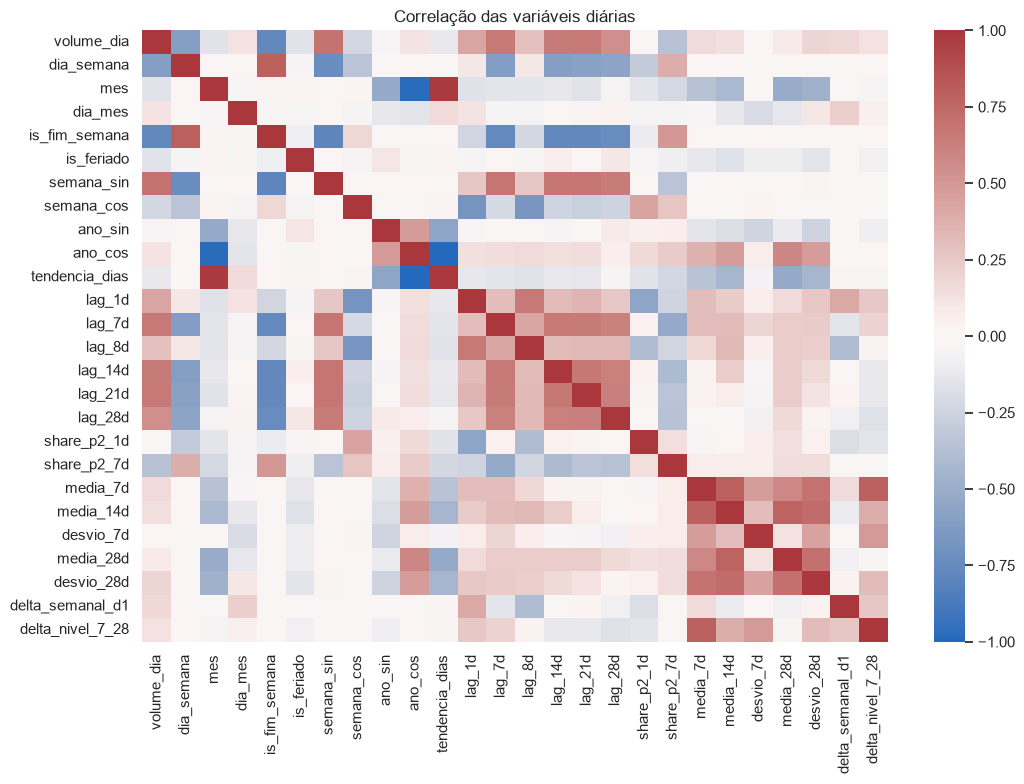

In [11]:
correlation_base = model_df.loc[:"2025-06-30"]
corr = correlation_base.corr(numeric_only=True, method="pearson")
spearman = correlation_base.corr(numeric_only=True, method="spearman")
target_corr = pd.DataFrame({
    "pearson": corr["volume_dia"].drop("volume_dia"),
    "spearman": spearman["volume_dia"].drop("volume_dia"),
}).sort_values("pearson", key=abs, ascending=False)
display(target_corr)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Correlação das variáveis diárias")
plt.tight_layout()
plt.show()

In [12]:
forbidden = {
    "volume_dia_corrente_como_feature", "Duração", "Resolvido", "Encerrado",
    "Código de fechamento", "Solução", "KPI Violado?",
}
feature_columns = [c for c in model_df.columns if c != "volume_dia"]
leakage_found = sorted(forbidden.intersection(feature_columns))
assert not leakage_found, f"Leakage encontrado: {leakage_found}"
rolling_check = daily["volume_dia"].shift(1).rolling(7).mean()
assert np.allclose(daily["media_7d"].dropna(), rolling_check.dropna())

leakage_audit = pd.DataFrame([
    ["Ordem temporal", True, "treino < validação < backtest"],
    ["Janelas encerradas em D−1", True, "shift(1) antes de rolling"],
    ["Alvo do dia fora das entradas", "volume_dia" not in feature_columns, "alvo separado de X"],
    ["Campos pós-incidente bloqueados", not leakage_found, ", ".join(sorted(forbidden - {"volume_dia_corrente_como_feature"}))],
    ["Scaler ajustado só no treino", True, "Pipeline sklearn treinado em train"],
], columns=["controle", "aprovado", "evidencia"])
display(leakage_audit)
assert leakage_audit["aprovado"].all()

,controle,aprovado,evidencia
0,Ordem temporal,True,treino < validação < backtest
1,Janelas encerradas em D−1,True,shift(1) antes de rolling
2,Alvo do dia fora das entradas,True,alvo separado de X
3,Campos pós-incidente bloqueados,True,"Código de fechamento, Duração, Encerrado, KPI ..."
4,Scaler ajustado só no treino,True,Pipeline sklearn treinado em train


## 7. Split temporal e modelos interpretáveis

A referência oficial do produto usa a mediana das três semanas anteriores para o mesmo dia da semana. Comparamos três famílias incrementais: calendário, calendário + lags e conjunto completo. O Ridge é apenas uma análise de sensibilidade à multicolinearidade; seu `alpha` é escolhido com validação expansiva dentro do treino. O terceiro trimestre confirma a configuração e o Q4 permanece isolado.

In [13]:
train = model_df.loc[:"2025-06-30"].copy()
validation = model_df.loc["2025-07-01":"2025-09-30"].copy()
backtest = model_df.loc["2025-10-01":"2025-12-31"].copy()
assert train.index.max() < validation.index.min() <= validation.index.max() < backtest.index.min()

display(pd.DataFrame({
    "início": [x.index.min().date() for x in (train, validation, backtest)],
    "fim": [x.index.max().date() for x in (train, validation, backtest)],
    "dias": [len(x) for x in (train, validation, backtest)],
    "volume_médio": [x.volume_dia.mean() for x in (train, validation, backtest)],
}, index=["treino", "validação", "backtest"]).round(2))

CALENDAR = ["is_fim_semana", "is_feriado", "semana_sin", "semana_cos"]
LAGS = ["lag_1d", "lag_7d", "lag_14d", "lag_21d", "lag_28d"]
COMPOSITION = ["share_p2_1d", "share_p2_7d"]
WINDOWS = ["media_7d", "media_14d", "media_28d", "desvio_7d", "desvio_28d"]
REGIME = ["delta_semanal_d1", "delta_nivel_7_28"]
FEATURE_SETS = {
    "calendario": CALENDAR,
    "calendario_lags": CALENDAR + LAGS,
    "completo": CALENDAR + LAGS + COMPOSITION + WINDOWS + REGIME,
}

def metrics(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    errors = np.asarray(y_true) - y_pred
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
        "WAPE_pct": 100 * np.abs(errors).sum() / np.asarray(y_true).sum(),
    }

def seasonal_baseline(frame):
    return np.median(
        np.column_stack([frame["lag_7d"], frame["lag_14d"], frame["lag_21d"]]),
        axis=1,
    )

q1_target, q3_target = train["volume_dia"].quantile([0.25, 0.75])
iqr_target = q3_target - q1_target
target_upper = q3_target + 1.5 * iqr_target
target_outliers = train.loc[train["volume_dia"] > target_upper, ["volume_dia"]]
display(pd.Series({
    "Q1_treino": q1_target,
    "Q3_treino": q3_target,
    "limite_superior_IQR_treino": target_upper,
    "picos_acima_limite": len(target_outliers),
    "decisão": "manter: picos são demanda operacional real",
}, name="outliers_do_alvo"))
display(target_outliers.sort_values("volume_dia", ascending=False).head(10))

,início,fim,dias,volume_médio
treino,2025-01-29,2025-06-30,153,73.35
validação,2025-07-01,2025-09-30,92,73.70
backtest,2025-10-01,2025-12-31,92,56.34


Q1_treino                                                           46.0
Q3_treino                                                           94.0
limite_superior_IQR_treino                                         166.0
picos_acima_limite                                                     1
decisão                       manter: picos são demanda operacional real
Name: outliers_do_alvo, dtype: object

,volume_dia
data,
2025-01-30,186


In [14]:
# Ridge: alpha escolhido exclusivamente em folds expansivos do treino.
tscv = TimeSeriesSplit(n_splits=4)
alpha_rows = []
for alpha in (0.1, 1.0, 10.0, 100.0):
    fold_mae = []
    for fit_idx, check_idx in tscv.split(train):
        ridge_cv = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=alpha))])
        ridge_cv.fit(train.iloc[fit_idx][FEATURE_SETS["completo"]], train.iloc[fit_idx].volume_dia)
        fold_pred = ridge_cv.predict(train.iloc[check_idx][FEATURE_SETS["completo"]])
        fold_mae.append(mean_absolute_error(train.iloc[check_idx].volume_dia, np.clip(fold_pred, 0, None)))
    alpha_rows.append({"alpha": alpha, "MAE_CV_medio": np.mean(fold_mae), "MAE_CV_pior_fold": np.max(fold_mae)})
alpha_results = pd.DataFrame(alpha_rows).sort_values(["MAE_CV_medio", "MAE_CV_pior_fold"])
best_alpha = float(alpha_results.iloc[0].alpha)
display(alpha_results.round(3))
print("Alpha congelado no treino:", best_alpha)

validation_rows = [{
    "modelo": "baseline_mediana_3_semanas",
    **metrics(validation.volume_dia, seasonal_baseline(validation)),
}]
candidates_models = {}
for set_name, features in FEATURE_SETS.items():
    for model_name, estimator in (("linear", LinearRegression()), (f"ridge_a{best_alpha:g}", Ridge(alpha=best_alpha))):
        pipe = Pipeline([("scale", StandardScaler()), ("model", estimator)])
        pipe.fit(train[features], train.volume_dia)
        pred = pipe.predict(validation[features])
        key = f"{set_name}__{model_name}"
        validation_rows.append({"modelo": key, **metrics(validation.volume_dia, pred)})
        candidates_models[key] = (pipe, features)

validation_results = pd.DataFrame(validation_rows).sort_values(["MAE", "RMSE"]).reset_index(drop=True)
display(validation_results.round(3))
regression_results = validation_results[validation_results.modelo.ne("baseline_mediana_3_semanas")]
selected_name = regression_results.iloc[0].modelo
selected_model, selected_features = candidates_models[selected_name]
validation_winner = validation_results.iloc[0].modelo
print("Vencedor geral na validação:", validation_winner)
print("Regressão congelada para interpretação/backtest:", selected_name)
print("Features:", selected_features)
if validation_winner == "baseline_mediana_3_semanas":
    print("A referência permaneceu superior; a regressão será avaliada sem alegação de promoção.")

,alpha,MAE_CV_medio,MAE_CV_pior_fold
3,100.0,16.293,22.041
2,10.0,18.264,33.802
1,1.0,20.290,41.736
0,0.1,20.954,44.077


Alpha congelado no treino: 100.0


,modelo,MAE,RMSE,R2,WAPE_pct
0,calendario_lags__linear,11.444,15.323,0.727,15.529
1,completo__ridge_a100,11.556,15.325,0.727,15.681
2,calendario_lags__ridge_a100,11.857,15.741,0.712,16.089
3,completo__linear,12.324,16.316,0.690,16.723
4,calendario__linear,12.791,16.581,0.680,17.356
5,baseline_mediana_3_semanas,12.967,17.323,0.651,17.596
6,calendario__ridge_a100,13.346,17.770,0.633,18.110


Vencedor geral na validação: calendario_lags__linear
Regressão congelada para interpretação/backtest: calendario_lags__linear
Features: ['is_fim_semana', 'is_feriado', 'semana_sin', 'semana_cos', 'lag_1d', 'lag_7d', 'lag_14d', 'lag_21d', 'lag_28d']


## 8. Backtest final

Após congelar a configuração, refazemos o ajuste com treino + validação e abrimos o quarto trimestre. A referência sazonal continua sendo comparada nas mesmas datas, em avaliação diária D+1 com histórico real disponível até D−1.

In [15]:
development = pd.concat([train, validation]).sort_index()
estimator = Ridge(alpha=best_alpha) if "ridge_a" in selected_name else LinearRegression()
final_model = Pipeline([("scale", StandardScaler()), ("model", estimator)])
final_model.fit(development[selected_features], development.volume_dia)

pred_model = np.clip(final_model.predict(backtest[selected_features]), 0, None)
pred_baseline = seasonal_baseline(backtest)
final_results = pd.DataFrame([
    {"modelo": "baseline_mediana_3_semanas", **metrics(backtest.volume_dia, pred_baseline)},
    {"modelo": selected_name, **metrics(backtest.volume_dia, pred_model)},
]).sort_values("MAE")
display(final_results.round(3))

mae_baseline = final_results.loc[final_results.modelo.eq("baseline_mediana_3_semanas"), "MAE"].iloc[0]
mae_model = final_results.loc[final_results.modelo.eq(selected_name), "MAE"].iloc[0]
print(f"Variação de MAE frente à referência: {(mae_model / mae_baseline - 1) * 100:+.2f}%")

,modelo,MAE,RMSE,R2,WAPE_pct
0,baseline_mediana_3_semanas,12.696,16.556,0.559,22.535
1,calendario_lags__linear,13.612,18.613,0.442,24.161


Variação de MAE frente à referência: +7.21%


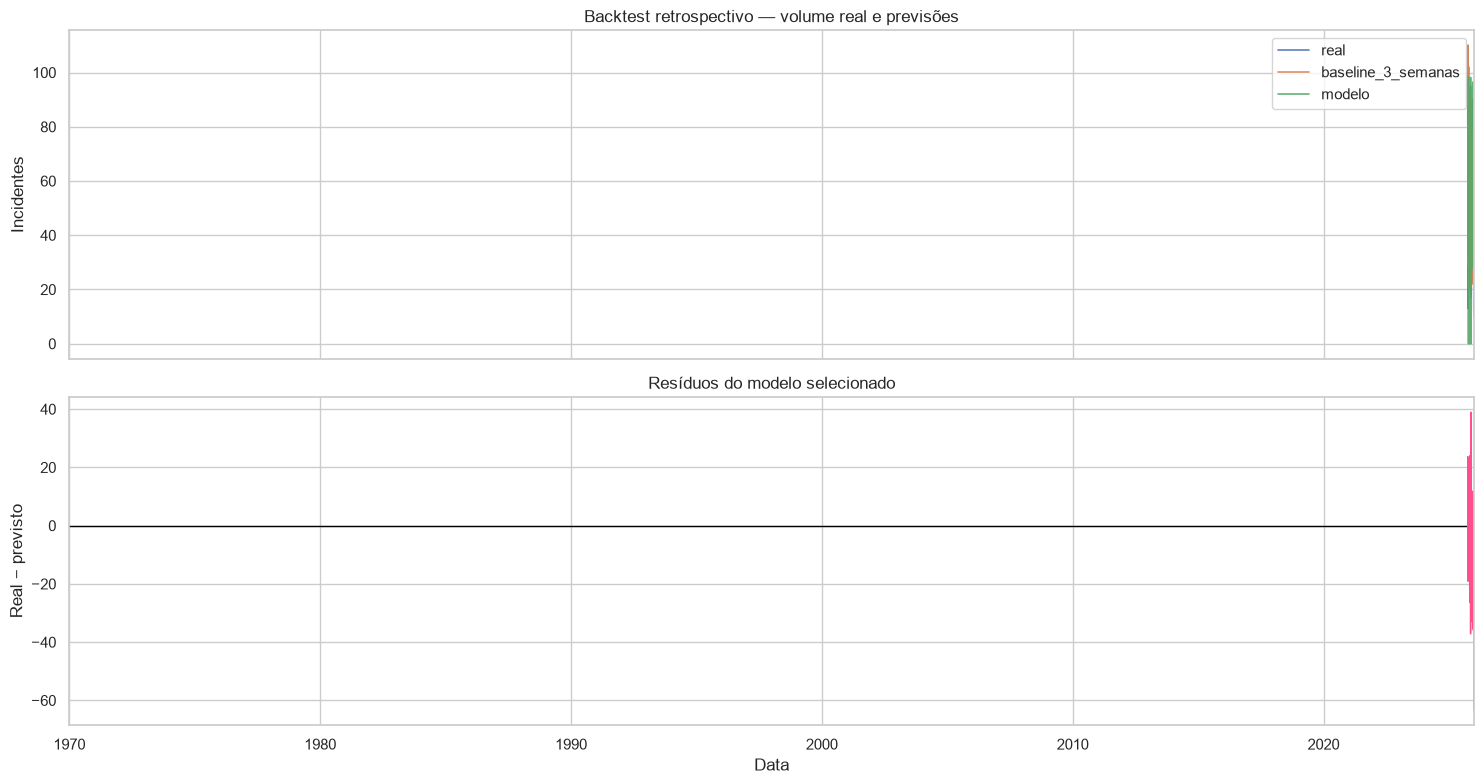

In [16]:
comparison = pd.DataFrame({
    "real": backtest.volume_dia,
    "baseline_3_semanas": pred_baseline,
    "modelo": pred_model,
}, index=backtest.index)
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
comparison.plot(ax=axes[0], lw=1.2, alpha=0.9)
axes[0].set(title="Backtest retrospectivo — volume real e previsões", ylabel="Incidentes")
residuals = comparison["real"] - comparison["modelo"]
axes[1].axhline(0, color="black", lw=1)
residuals.plot(ax=axes[1], color="#ff4d8d", lw=1)
axes[1].set(title="Resíduos do modelo selecionado", ylabel="Real − previsto", xlabel="Data")
plt.tight_layout()
plt.show()

## 9. Importância, pressupostos e resíduos

Como as entradas são padronizadas pelo `StandardScaler`, os coeficientes podem ser comparados em uma escala comum: o valor representa a mudança esperada no volume para um desvio-padrão da feature, mantendo as demais constantes. Isso não prova causalidade, sobretudo quando lags e médias móveis são correlacionados.

,feature,coeficiente_padronizado
0,is_fim_semana,-19.431
4,lag_1d,9.114
3,semana_cos,4.926
1,is_feriado,-4.724
5,lag_7d,2.651
6,lag_14d,2.387
8,lag_28d,-0.774
7,lag_21d,0.059
2,semana_sin,-0.033


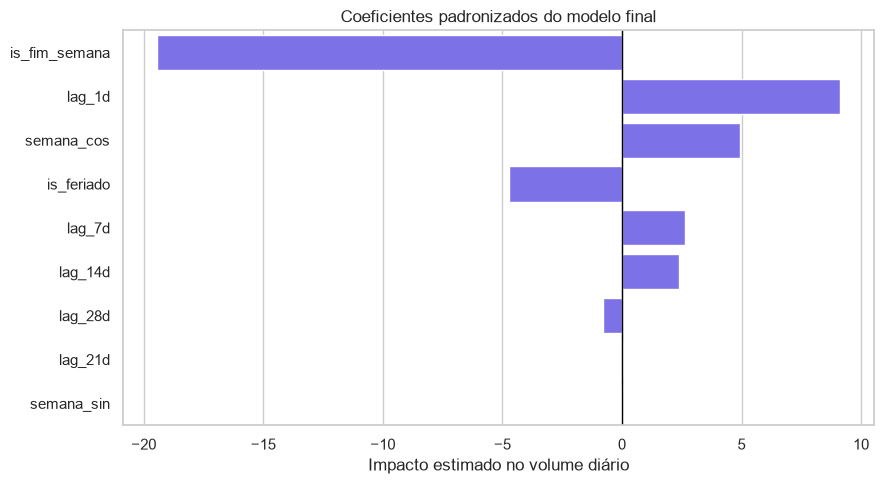

In [17]:
coefficients = pd.DataFrame({
    "feature": selected_features,
    "coeficiente_padronizado": final_model.named_steps["model"].coef_,
})
coefficients["magnitude"] = coefficients["coeficiente_padronizado"].abs()
coefficients = coefficients.sort_values("magnitude", ascending=False)
display(coefficients.drop(columns="magnitude").round(3))

plt.figure(figsize=(9, 5))
sns.barplot(data=coefficients, y="feature", x="coeficiente_padronizado", color="#6d5dfc")
plt.axvline(0, color="black", lw=1)
plt.title("Coeficientes padronizados do modelo final")
plt.xlabel("Impacto estimado no volume diário")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [18]:
# VIF e OLS são diagnósticos de interpretação, não uma segunda seleção no backtest.
scaled_development = final_model.named_steps["scale"].transform(development[selected_features])
vif = pd.DataFrame({
    "feature": selected_features,
    "VIF": [variance_inflation_factor(scaled_development, i) for i in range(scaled_development.shape[1])],
}).sort_values("VIF", ascending=False)
display(vif.round(2))

ols_diagnostic = sm.OLS(development.volume_dia.to_numpy(), sm.add_constant(scaled_development)).fit()
ols_coefficients = pd.DataFrame({
    "feature": ["constante"] + selected_features,
    "coeficiente": ols_diagnostic.params,
    "p_valor": ols_diagnostic.pvalues,
    "IC95_inferior": ols_diagnostic.conf_int()[:, 0],
    "IC95_superior": ols_diagnostic.conf_int()[:, 1],
})
display(ols_coefficients.round(4))
print(f"R² OLS no desenvolvimento: {ols_diagnostic.rsquared:.4f} | R² ajustado: {ols_diagnostic.rsquared_adj:.4f}")
print("Nota: p-valores ficam frágeis quando há autocorrelação, heterocedasticidade ou VIF alto.")

,feature,VIF
0,is_fim_semana,6.50
2,semana_sin,3.74
7,lag_21d,3.09
6,lag_14d,3.09
5,lag_7d,2.94
8,lag_28d,2.73
4,lag_1d,2.32
3,semana_cos,2.27
1,is_feriado,1.03


,feature,coeficiente,p_valor,IC95_inferior,IC95_superior
0,constante,73.4816,0.0000,71.4646,75.4986
1,is_fim_semana,-19.4315,0.0000,-24.5731,-14.2899
2,is_feriado,-4.7240,0.0000,-6.7684,-2.6796
3,semana_sin,-0.0331,0.9867,-3.9323,3.8662
4,semana_cos,4.9256,0.0016,1.8880,7.9631
5,lag_1d,9.1137,0.0000,6.0396,12.1879
6,lag_7d,2.6511,0.1325,-0.8086,6.1109
7,lag_14d,2.3871,0.1858,-1.1571,5.9313
8,lag_21d,0.0586,0.9741,-3.4873,3.6045
9,lag_28d,-0.7742,0.6475,-4.1058,2.5574


R² OLS no desenvolvimento: 0.7293 | R² ajustado: 0.7189
Nota: p-valores ficam frágeis quando há autocorrelação, heterocedasticidade ou VIF alto.


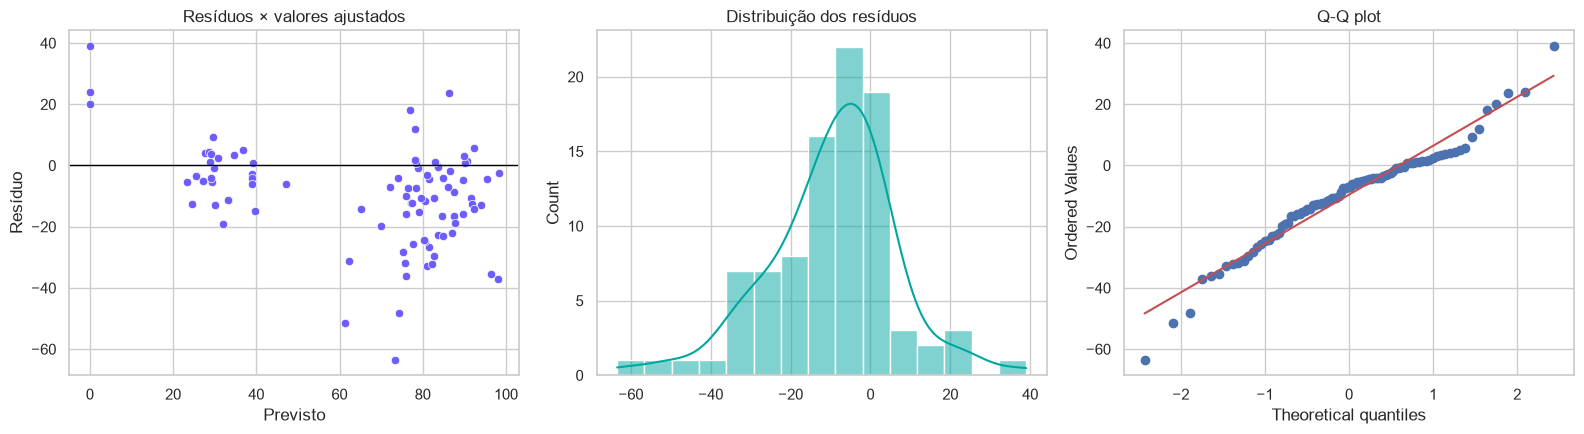

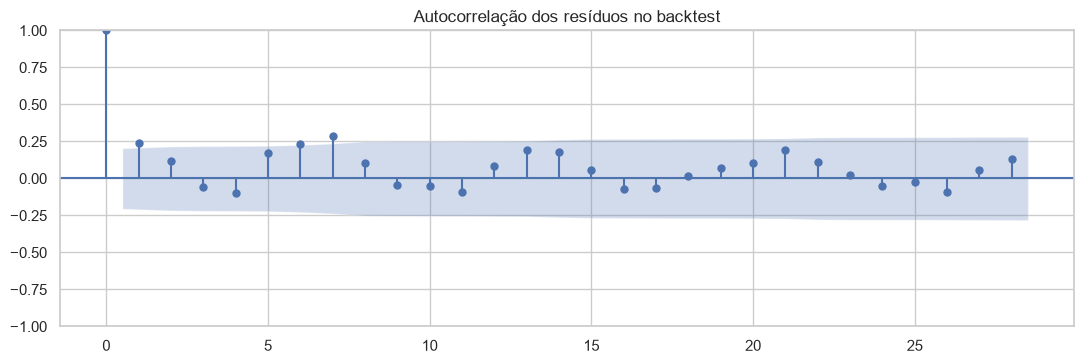

Durbin–Watson dos resíduos: 1.065 (2 sugere ausência de autocorrelação de primeira ordem)


In [19]:
fitted = pred_model
residuals = backtest.volume_dia.to_numpy() - fitted
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.scatterplot(x=fitted, y=residuals, ax=axes[0], color="#6d5dfc")
axes[0].axhline(0, color="black", lw=1)
axes[0].set(title="Resíduos × valores ajustados", xlabel="Previsto", ylabel="Resíduo")
sns.histplot(residuals, kde=True, ax=axes[1], color="#00a7a0")
axes[1].set_title("Distribuição dos resíduos")
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 3.8))
plot_acf(residuals, lags=28, ax=ax, alpha=0.05)
ax.set_title("Autocorrelação dos resíduos no backtest")
plt.tight_layout()
plt.show()
print(f"Durbin–Watson dos resíduos: {durbin_watson(residuals):.3f} (2 sugere ausência de autocorrelação de primeira ordem)")

In [20]:
error_audit = comparison.assign(
    erro_abs=(comparison["real"] - comparison["modelo"]).abs(),
    dia_semana=comparison.index.day_name(),
).sort_values("erro_abs", ascending=False).head(10)
display(error_audit.round(2))

,real,baseline_3_semanas,modelo,erro_abs,dia_semana
data,,,,,
2025-12-30,10,61.0,73.43,63.43,Tuesday
2025-12-31,10,56.0,61.40,51.40,Wednesday
2025-12-29,26,69.0,74.33,48.33,Monday
2025-11-15,39,29.0,0.00,39.00,Saturday
2025-11-11,61,85.0,98.18,37.18,Tuesday
2025-12-24,40,62.0,76.03,36.03,Wednesday
2025-12-16,61,74.0,96.51,35.51,Tuesday
2025-11-19,48,69.0,80.94,32.94,Wednesday
2025-12-22,50,69.0,82.29,32.29,Monday


## 10. Diagnóstico de drift

Seguindo a aula de Feature Selection e Drift, comparamos as distribuições das features escolhidas sem usar esse diagnóstico para mudar o modelo após abrir o backtest. O teste KS é apenas um sinal de alerta; múltiplos testes, dependência temporal e amostra curta impedem uma leitura automática de causalidade.

In [21]:
drift_rows = []
for feature in selected_features:
    ks_val, p_val = stats.ks_2samp(train[feature], backtest[feature])
    train_std = train[feature].std(ddof=0)
    standardized_shift = (
        (backtest[feature].mean() - train[feature].mean()) / train_std
        if train_std > 0 else np.nan
    )
    drift_rows.append({
        "feature": feature,
        "familia": "calendario" if feature in CALENDAR else "operacional",
        "media_treino": train[feature].mean(),
        "media_backtest": backtest[feature].mean(),
        "shift_desvios": standardized_shift,
        "KS": ks_val,
        "p_valor_KS": p_val,
    })
drift = pd.DataFrame(drift_rows).sort_values("KS", ascending=False)
display(drift.round(4))
operational_drift = drift.loc[drift["familia"].eq("operacional")].copy()
display(operational_drift.round(4))
print(
    "Leitura: calendário conhecido não é tratado como falha de dados. "
    "O alerta de drift operacional considera apenas lags, janelas, composição e mudanças de nível."
)

,feature,familia,media_treino,media_backtest,shift_desvios,KS,p_valor_KS
4,lag_1d,operacional,73.5294,57.1413,-0.5333,0.3337,0.0000
5,lag_7d,operacional,73.9673,60.7065,-0.4342,0.3054,0.0000
6,lag_14d,operacional,74.7908,64.1196,-0.3517,0.2641,0.0005
7,lag_21d,operacional,74.7843,66.2717,-0.2821,0.2489,0.0013
8,lag_28d,operacional,73.1699,66.8804,-0.2022,0.2119,0.0096
1,is_feriado,calendario,0.0196,0.0543,0.2506,0.0347,1.0000
2,semana_sin,calendario,-0.0051,0.0106,0.0222,0.0124,1.0000
3,semana_cos,calendario,-0.0041,-0.0024,0.0023,0.0075,1.0000
0,is_fim_semana,calendario,0.2876,0.2826,-0.0110,0.0050,1.0000


,feature,familia,media_treino,media_backtest,shift_desvios,KS,p_valor_KS
4,lag_1d,operacional,73.5294,57.1413,-0.5333,0.3337,0.0000
5,lag_7d,operacional,73.9673,60.7065,-0.4342,0.3054,0.0000
6,lag_14d,operacional,74.7908,64.1196,-0.3517,0.2641,0.0005
7,lag_21d,operacional,74.7843,66.2717,-0.2821,0.2489,0.0013
8,lag_28d,operacional,73.1699,66.8804,-0.2022,0.2119,0.0096


Leitura: calendário conhecido não é tratado como falha de dados. O alerta de drift operacional considera apenas lags, janelas, composição e mudanças de nível.


In [22]:
validation_baseline_mae = validation_results.loc[
    validation_results.modelo.eq("baseline_mediana_3_semanas"), "MAE"
].iloc[0]
validation_model_mae = validation_results.loc[
    validation_results.modelo.eq(selected_name), "MAE"
].iloc[0]
summary = pd.Series({
    "configuração_congelada": selected_name,
    "MAE_modelo_validação": validation_model_mae,
    "MAE_baseline_validação": validation_baseline_mae,
    "ganho_modelo_validação_pct": 100 * (1 - validation_model_mae / validation_baseline_mae),
    "MAE_modelo_Q4": mae_model,
    "MAE_baseline_Q4": mae_baseline,
    "piora_modelo_Q4_pct": 100 * (mae_model / mae_baseline - 1),
    "Durbin_Watson_Q4": durbin_watson(residuals),
    "decisão": "não promover; baseline sazonal permanece como referência",
}, name="resumo_executivo")
display(summary)
print(
    "Interpretação: a regressão selecionada confirmou utilidade das features em julho–setembro, "
    "mas não generalizou para a queda de nível do Q4. Fim de semana e volume D−1 "
    "foram os maiores sinais do modelo; resíduos autocorrelacionados e drift mostram "
    "que ainda falta dinâmica temporal. O resultado é evidência contra a promoção."
)

configuração_congelada                                  calendario_lags__linear
MAE_modelo_validação                                                  11.444359
MAE_baseline_validação                                                12.967391
ganho_modelo_validação_pct                                            11.745091
MAE_modelo_Q4                                                         13.611503
MAE_baseline_Q4                                                       12.695652
piora_modelo_Q4_pct                                                    7.213892
Durbin_Watson_Q4                                                       1.064696
decisão                       não promover; baseline sazonal permanece como ...
Name: resumo_executivo, dtype: object

Interpretação: a regressão selecionada confirmou utilidade das features em julho–setembro, mas não generalizou para a queda de nível do Q4. Fim de semana e volume D−1 foram os maiores sinais do modelo; resíduos autocorrelacionados e drift mostram que ainda falta dinâmica temporal. O resultado é evidência contra a promoção.


## 11. Conclusão e integração com o Predictfy

O experimento mede, de forma separada, quanto calendário, lags e janelas históricas acrescentam à mediana das três semanas anteriores. A decisão final deve ser lida nas tabelas executadas acima: treino e validação encerram toda escolha, enquanto o Q4 é aberto somente depois do congelamento.

**Uso no produto:** as features avaliadas podem alimentar novos experimentos do pipeline de previsão de volume e apoiar Gestão/Monitoramento. Esta regressão é um instrumento de interpretação e um baseline acadêmico; ela **não substitui automaticamente** o baseline sazonal, Prophet ou LSTM registrados no MVP. Promoção exige comparação no mesmo holdout, contrato de artefato, monitoramento de drift e validação prospectiva.

**Limitações:** somente 2025 possui cobertura operacional suficiente; feriados estaduais não capturam eventos internos; faltam mudanças planejadas, campanhas e incidentes externos; choques raros podem dominar o erro; tendência linear pode extrapolar mal; features são correlacionadas; o backtest já era conhecido pelo projeto. Nenhum coeficiente deve ser tratado como efeito causal.

**Próximo passo seguro:** congelar este pipeline e avaliá-lo em dados de 2026 ainda não consultados, comparando MAE, WAPE e pior semana com os modelos registrados no Predictfy.